In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import train_test_split

In [9]:
df_acre = pd.read_csv("base_dados/MICRODADOS_ENEM_2023_AC.csv")

In [ ]:
# Criando uma nova feature 
notas_objetivas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT']
df_acre[notas_objetivas] = df_acre[notas_objetivas].fillna(0) # Tratamento de ausentes (imputação com zero)
df_acre['NOTA_MEDIA_OBJ'] = df_acre[notas_objetivas].mean(axis=1)

In [ ]:
# Split: Separação de treino e teste
X = df_acre[['TP_SEXO', 'TP_ESCOLA', 'Q001', 'Q002', 'Q006', 'NU_NOTA_CN', 'NU_NOTA_CH']] # Exemplo de subset
y = df_acre['NOTA_MEDIA_OBJ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# One-Hot Encoding (Nominal) para Variáveis sem hierarquia
cols_nominais = ['TP_SEXO', 'TP_ESCOLA']
X_train = pd.get_dummies(X_train, columns=cols_nominais, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_nominais, drop_first=True)

# Alinhamento das colunas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [ ]:
# Usando as categorias literais do Dicionário do INEP
ordem_instrucao = [['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']]
ordem_renda = [['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q']]

enc_instrucao = OrdinalEncoder(categories=ordem_instrucao)
enc_renda = OrdinalEncoder(categories=ordem_renda)

# Fit apenas no treino, Transform no treino e teste
X_train['Q001_Enc'] = enc_instrucao.fit_transform(X_train[['Q001']])
X_test['Q001_Enc'] = enc_instrucao.transform(X_test[['Q001']])

X_train['Q006_Enc'] = enc_renda.fit_transform(X_train[['Q006']])
X_test['Q006_Enc'] = enc_renda.transform(X_test[['Q006']])

# Removendo as colunas de texto originais
X_train = X_train.drop(columns=['Q001', 'Q002', 'Q006'])
X_test = X_test.drop(columns=['Q001', 'Q002', 'Q006'])


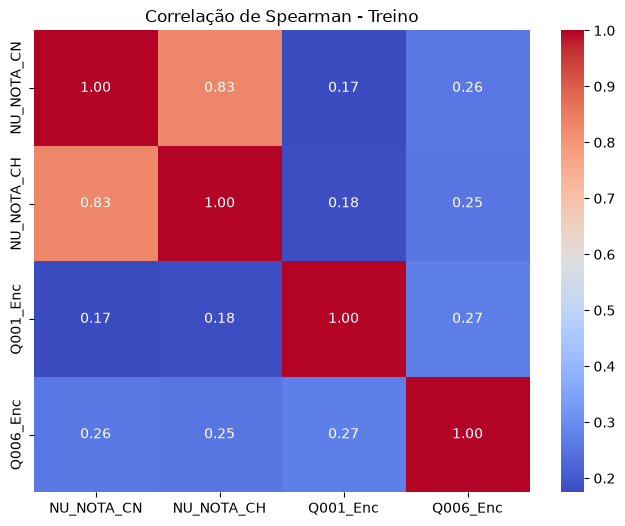

In [ ]:
# Usando StandardScaler nas colunas numéricas originais
std_features = ['NU_NOTA_CN', 'NU_NOTA_CH']
std = StandardScaler()

X_train[std_features] = std.fit_transform(X_train[std_features])
X_test[std_features] = std.transform(X_test[std_features])

# Matriz de Correlação de Spearman 
numericas = X_train.select_dtypes(include=np.number).columns
matriz = X_train[numericas].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação de Spearman - Treino')
plt.show()